Section f - Sensitivity to a global CO2 constraint

Based on the single-country / one-node model from Section c

In [1]:
# Imports and paths

from pathlib import Path
import pandas as pd
pd.options.future.infer_string = False
import matplotlib.pyplot as plt
import pypsa
import re
import math
import numpy as np

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR.parent / "data"
PLOTS_DIR = BASE_DIR.parent / "Plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

GENERATION_FILE = DATA_DIR / "energy-charts_Total_net_electricity_generation_in_Germany_in_2024.csv"
LOAD_FILE = DATA_DIR / "energy-charts_Total_net_electricity_generation_in_Germany_in_2024_load.csv"

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("GENERATION_FILE exists:", GENERATION_FILE.exists())
print("LOAD_FILE exists:", LOAD_FILE.exists())

BASE_DIR: c:\Users\eleor\OneDrive - Danmarks Tekniske Universitet\Sustainable Energy Systems\2nd SEM\Integrated energy grids\Assignment\Integrated_Energy_Grids-1\Modules
DATA_DIR: c:\Users\eleor\OneDrive - Danmarks Tekniske Universitet\Sustainable Energy Systems\2nd SEM\Integrated energy grids\Assignment\Integrated_Energy_Grids-1\data
PLOTS_DIR: c:\Users\eleor\OneDrive - Danmarks Tekniske Universitet\Sustainable Energy Systems\2nd SEM\Integrated energy grids\Assignment\Integrated_Energy_Grids-1\Plots
GENERATION_FILE exists: True
LOAD_FILE exists: True


In [2]:

# Data loading and cleaning

print("Reading files...")
print("Generation file:", GENERATION_FILE)
print("Load file:", LOAD_FILE)

gen_raw = pd.read_csv(GENERATION_FILE)
load_raw = pd.read_csv(LOAD_FILE)

gen_raw.columns = [str(c).strip() for c in gen_raw.columns]
load_raw.columns = [str(c).strip() for c in load_raw.columns]

print("\nGeneration columns:")
print(gen_raw.columns.tolist())

print("\nLoad columns:")
print(load_raw.columns.tolist())

GENERATION_TIME_COL = gen_raw.columns[0]
LOAD_TIME_COL = load_raw.columns[0]

WIND_OFFSHORE_COL = "Wind offshore"
WIND_ONSHORE_COL = "Wind onshore"
SOLAR_COL = "Solar"
LOAD_COL = "Load"


def parse_time(series):
    try:
        return pd.to_datetime(series, errors="coerce", utc=True, format="mixed")
    except Exception:
        return pd.to_datetime(series, errors="coerce", utc=True)


def parse_number(series):
    s = series.astype(str).str.strip()
    s = s.str.replace("\u202f", "", regex=False)
    s = s.str.replace("\xa0", "", regex=False)
    s = s.str.replace(" ", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")


gen_raw[GENERATION_TIME_COL] = parse_time(gen_raw[GENERATION_TIME_COL])
load_raw[LOAD_TIME_COL] = parse_time(load_raw[LOAD_TIME_COL])

gen_raw = gen_raw.dropna(subset=[GENERATION_TIME_COL]).copy()
load_raw = load_raw.dropna(subset=[LOAD_TIME_COL]).copy()

gen_raw = gen_raw.set_index(GENERATION_TIME_COL)
load_raw = load_raw.set_index(LOAD_TIME_COL)

if getattr(gen_raw.index, "tz", None) is not None:
    gen_raw.index = gen_raw.index.tz_convert("Europe/Berlin").tz_localize(None)
    gen_raw.index.name = "Date"

if getattr(load_raw.index, "tz", None) is not None:
    load_raw.index = load_raw.index.tz_convert("Europe/Berlin").tz_localize(None)
    load_raw.index.name = "Date"

gen = pd.DataFrame(index=gen_raw.index)
gen["wind_offshore"] = parse_number(gen_raw[WIND_OFFSHORE_COL])
gen["wind_onshore"] = parse_number(gen_raw[WIND_ONSHORE_COL])
gen["solar"] = parse_number(gen_raw[SOLAR_COL])

load = pd.DataFrame(index=load_raw.index)
load["load"] = parse_number(load_raw[LOAD_COL])

df = gen.join(load, how="inner")
df = df.dropna().copy()
df = df.groupby(df.index).mean()
df = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")].copy()

# Convert 15-minute data to hourly averages
df = df.resample("1h").mean()
df = df.interpolate(method="time")

# Remove Feb 29 so the year has 8760 hours
df = df[~((df.index.month == 2) & (df.index.day == 29))].copy()

print("\nFirst rows:")
print(df.head())

print("\nShape:")
print(df.shape)

Reading files...
Generation file: c:\Users\eleor\OneDrive - Danmarks Tekniske Universitet\Sustainable Energy Systems\2nd SEM\Integrated energy grids\Assignment\Integrated_Energy_Grids-1\data\energy-charts_Total_net_electricity_generation_in_Germany_in_2024.csv
Load file: c:\Users\eleor\OneDrive - Danmarks Tekniske Universitet\Sustainable Energy Systems\2nd SEM\Integrated energy grids\Assignment\Integrated_Energy_Grids-1\data\energy-charts_Total_net_electricity_generation_in_Germany_in_2024_load.csv

Generation columns:
['Date (GMT+1)', 'Wind offshore', 'Wind onshore', 'Solar']

Load columns:
['Date (GMT+1)', 'Load']

First rows:
                     wind_offshore  wind_onshore  solar       load
Date                                                              
2024-01-01 00:00:00       5682.425     29106.525    0.0  42896.250
2024-01-01 01:00:00       5348.775     29017.375    0.0  41452.550
2024-01-01 02:00:00       5191.500     29096.325    0.0  40416.100
2024-01-01 03:00:00       46

In [3]:
# Capacity factors for the one-node model
# Uses 2024 observed maxima as available capacity proxies

installed_capacity = {
    "wind_onshore": df["wind_onshore"].max(),
    "wind_offshore": df["wind_offshore"].max(),
    "solar": df["solar"].max(),
}

df_model = pd.DataFrame(index=df.index)
df_model["load"] = df["load"]
df_model["cf_onshore"] = (df["wind_onshore"] / installed_capacity["wind_onshore"]).clip(lower=0, upper=1)
df_model["cf_offshore"] = (df["wind_offshore"] / installed_capacity["wind_offshore"]).clip(lower=0, upper=1)
df_model["cf_solar"] = (df["solar"] / installed_capacity["solar"]).clip(lower=0, upper=1)

print(df_model.head())

                          load  cf_onshore  cf_offshore  cf_solar
Date                                                             
2024-01-01 00:00:00  42896.250    0.640509     0.767742  0.000000
2024-01-01 01:00:00  41452.550    0.638548     0.722663  0.000000
2024-01-01 02:00:00  40416.100    0.640285     0.701414  0.000000
2024-01-01 03:00:00  39642.625    0.628686     0.631867  0.000000
2024-01-01 04:00:00  39247.775    0.627222     0.600134  0.000038


In [4]:
#  Helper functions

def annuity(n, r):
    if r > 0:
        return r / (1 - (1 + r) ** (-n))
    return 1 / n


def pick_solver():
    # Tries Gurobi first, then HiGHS
    for solver in ["gurobi", "highs"]:
        try:
            return solver
        except Exception:
            pass
    return "highs"

In [5]:
# Build the one-node Germany model
# - No exogenous CO2 price in gas marginal cost
# - CO2 signal comes from the global constraint

def build_germany_one_node_model(df_input):
    network = pypsa.Network()
    network.set_snapshots(df_input.index)

    network.add("Bus", "electricity bus")

    network.add(
        "Load",
        "load",
        bus="electricity bus",
        p_set=df_input["load"].values
    )

    # Carriers
    network.add("Carrier", "onshorewind")
    network.add("Carrier", "offshorewind")
    network.add("Carrier", "solar")
    network.add("Carrier", "battery")
    network.add("Carrier", "gas", co2_emissions=0.19)  # tCO2/MWh_th

    # Techno-economic assumptions

    r = 0.07   #discount rate

    capex_onshore = 910000
    fom_onshore = 0.033
    lifetime_onshore = 30

    capex_offshore = 2506000 
    fom_offshore = 0.033
    lifetime_offshore = 25

    capex_solar = 425000
    fom_solar = 0.03
    lifetime_solar = 25

    capex_gas = 560000
    fom_gas = 0.033
    lifetime_gas = 25

    capital_cost_onshore = annuity(lifetime_onshore, r) * capex_onshore * (1 + fom_onshore)
    capital_cost_offshore = annuity(lifetime_offshore, r) * capex_offshore * (1 + fom_offshore)
    capital_cost_solar = annuity(lifetime_solar, r) * capex_solar * (1 + fom_solar)
    capital_cost_gas = annuity(lifetime_gas, r) * capex_gas * (1 + fom_gas)

    fuel_cost_gas = 21.6
    efficiency_gas = 0.39

    # no exogenous CO2 price here
    marginal_cost_gas = fuel_cost_gas / efficiency_gas

    # Generators
    network.add(
        "Generator",
        "onshorewind",
        bus="electricity bus",
        carrier="onshorewind",
        p_nom_extendable=True,
        capital_cost=capital_cost_onshore,
        marginal_cost=0.0,
        p_max_pu=df_input["cf_onshore"].values
    )

    network.add(
        "Generator",
        "offshorewind",
        bus="electricity bus",
        carrier="offshorewind",
        p_nom_extendable=True,
        capital_cost=capital_cost_offshore,
        marginal_cost=0.0,
        p_max_pu=df_input["cf_offshore"].values
    )

    network.add(
        "Generator",
        "solar",
        bus="electricity bus",
        carrier="solar",
        p_nom_extendable=True,
        capital_cost=capital_cost_solar,
        marginal_cost=0.0,
        p_max_pu=df_input["cf_solar"].values
    )

    network.add(
        "Generator",
        "gas",
        bus="electricity bus",
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=capital_cost_gas,
        marginal_cost=marginal_cost_gas,
        efficiency=efficiency_gas
    )

    # Battery 
    n_bess = 15
    hmax = 6
    eta_ch = 0.90
    eta_dis = 0.90
    c_energy = 144600
    c_inverter = 310000
    fom_bess = 0.03

    battery_power_cost = annuity(n_bess, r) * (c_energy * hmax + c_inverter) * (1 + fom_bess)

    network.add(
        "StorageUnit",
        "battery",
        bus="electricity bus",
        carrier="battery",
        p_nom_extendable=True,
        max_hours=hmax,
        efficiency_store=eta_ch,
        efficiency_dispatch=eta_dis,
        cyclic_state_of_charge=True,
        capital_cost=battery_power_cost
    )

    return network

In [6]:
# Solve one case

def solve_case(df_input, co2_cap_tonnes=None, solver_name=None):
    if solver_name is None:
        solver_name = pick_solver()

    network = build_germany_one_node_model(df_input)

    if co2_cap_tonnes is not None:
        network.add(
            "GlobalConstraint",
            "co2_limit",
            type="primary_energy",
            carrier_attribute="co2_emissions",
            sense="<=",
            constant=co2_cap_tonnes
        )

    def _to_object_index(idx):
        if hasattr(idx, "dtype") and str(idx.dtype).startswith("string"):
            return idx.astype("object")
        return idx

    # Compatibility fix: avoid ArrowStringArray reaching xarray internals
    for component in network.components.values():
        static = getattr(network, component.list_name, None)
        if static is None or static.empty:
            continue

        static.index = _to_object_index(static.index)
        static.columns = _to_object_index(static.columns)

        for col in static.columns:
            if str(static[col].dtype).startswith("string"):
                static[col] = static[col].astype("object")

    network.optimize(solver_name=solver_name)

    annual_generation = network.generators_t.p.sum()

    capacities = network.generators.p_nom_opt.copy()
    if "battery" in network.storage_units.index:
        capacities["battery"] = network.storage_units.at["battery", "p_nom_opt"]

    gas_generation = network.generators_t.p["gas"].sum() if "gas" in network.generators_t.p.columns else 0.0
    gas_efficiency = network.generators.at["gas", "efficiency"]
    total_emissions = gas_generation / gas_efficiency * network.carriers.at["gas", "co2_emissions"]

    mu_co2 = np.nan
    if "co2_limit" in network.global_constraints.index:
        mu_co2 = -float(network.global_constraints.at["co2_limit", "mu"])

    return {
        "network": network,
        "annual_generation": annual_generation,
        "capacities": capacities,
        "total_emissions": total_emissions,
        "mu_co2": mu_co2
    }


In [8]:
# Baseline run

SOLVER = "highs"  

baseline = solve_case(df_model, co2_cap_tonnes=None, solver_name=SOLVER)
baseline_emissions = baseline["total_emissions"]

print("Baseline total CO2 emissions [tCO2]:", baseline_emissions)
print("\nBaseline capacities [MW]:")
print(baseline["capacities"])

C:\Users\eleor\AppData\Local\Temp\ipykernel_85160\2843850475.py:37: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['electricity bus'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 181.39it/s]
INFO:linopy.io: Writing time: 0.22s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140165 duals
Objective: 2.39e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageU

Baseline total CO2 emissions [tCO2]: 85372290.44312114

Baseline capacities [MW]:
name
onshorewind     102874.679310
offshorewind        -0.000000
solar            76580.584597
gas              71422.667013
battery             -0.000000
Name: p_nom_opt, dtype: float64


In [ ]:
# Sensitivity runs for section f)

cap_shares = [1.00, 0.75, 0.50, 0.25, 0.10, 0.05, 0.00]
results = []

for share in cap_shares:
    co2_cap = share * baseline_emissions
    case = solve_case(df_model, co2_cap_tonnes=co2_cap, solver_name=SOLVER)

    results.append({
        "co2_cap_share": share,
        "co2_cap_tonnes": co2_cap,
        "co2_emissions_tonnes": case["total_emissions"],
        "mu_co2_eur_per_tco2": case["mu_co2"],
        "cap_onshore_mw": case["capacities"].get("onshorewind", 0.0),
        "cap_offshore_mw": case["capacities"].get("offshorewind", 0.0),
        "cap_solar_mw": case["capacities"].get("solar", 0.0),
        "cap_gas_mw": case["capacities"].get("gas", 0.0),
        "cap_battery_mw": case["capacities"].get("battery", 0.0),
        "gen_onshore_mwh": case["annual_generation"].get("onshorewind", 0.0),
        "gen_offshore_mwh": case["annual_generation"].get("offshorewind", 0.0),
        "gen_solar_mwh": case["annual_generation"].get("solar", 0.0),
        "gen_gas_mwh": case["annual_generation"].get("gas", 0.0),
    })

results_df = pd.DataFrame(results)
results_df.to_csv(PLOTS_DIR / "section_f_co2_sensitivity_results.csv", index=False)

print(results_df)

C:\Users\eleor\AppData\Local\Temp\ipykernel_85092\625600872.py:36: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['electricity bus'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 235.10it/s]
INFO:linopy.io: Writing time: 0.18s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140166 duals
Objective: 2.39e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUn

   co2_cap_share  co2_cap_tonnes  co2_emissions_tonnes  mu_co2_eur_per_tco2  \
0           1.00    8.537229e+07          8.537229e+07             0.010624   
1           0.75    6.402922e+07          6.402922e+07            54.673245   
2           0.50    4.268615e+07          4.268615e+07           140.219839   
3           0.25    2.134307e+07          2.134307e+07           385.904423   
4           0.10    8.537229e+06          8.537229e+06          1198.357247   
5           0.05    4.268615e+06          4.268615e+06          3228.163561   
6           0.00    0.000000e+00          0.000000e+00         33259.965827   

   cap_onshore_mw  cap_offshore_mw   cap_solar_mw    cap_gas_mw  \
0   102874.679310        -0.000000   76580.584597  71422.667013   
1   130547.727969        -0.000000   91369.443364  66980.528341   
2   151483.947887      7932.576129  113826.114807  60680.272241   
3   168363.250598      9939.301856  167116.417300  53977.147038   
4   160916.734791     40279.3040

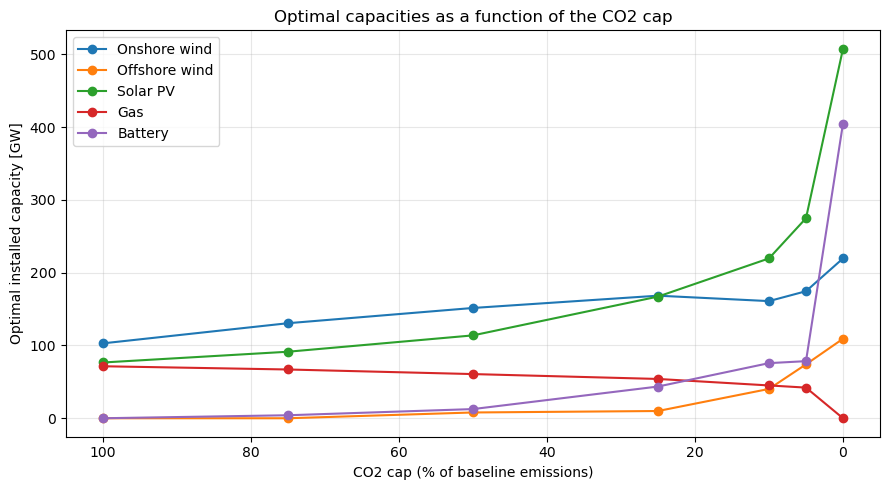

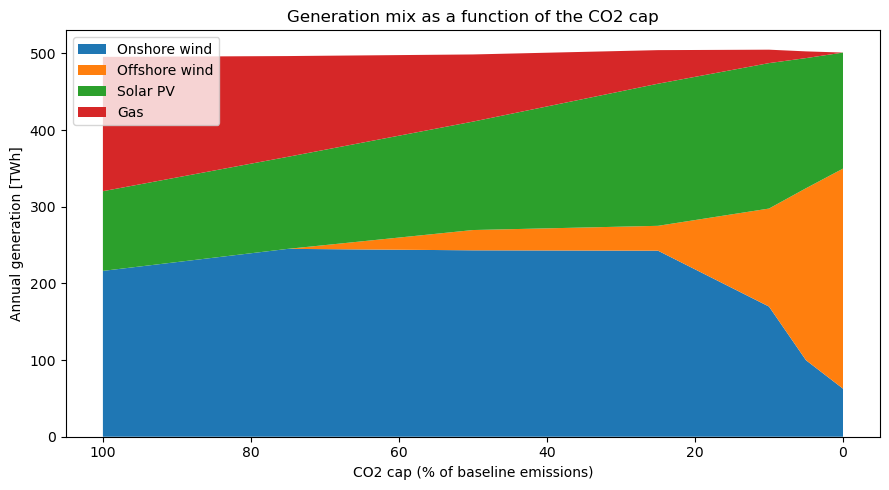

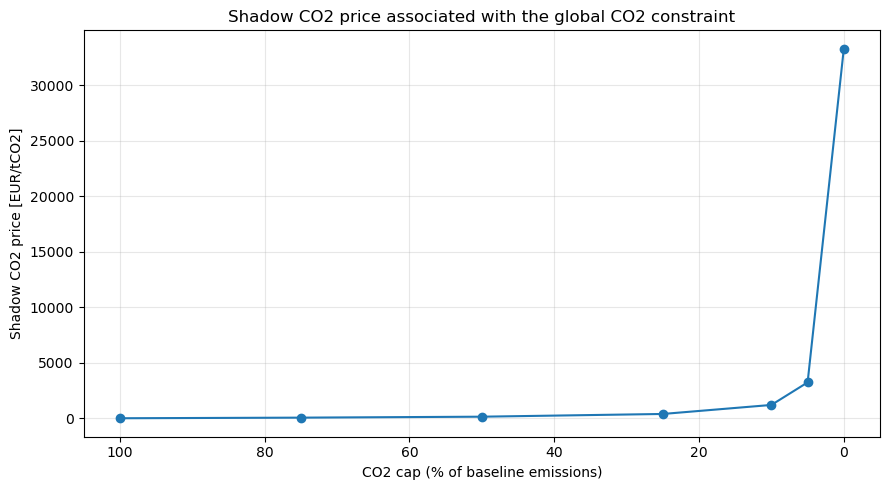

In [ ]:
# Plots

plt.figure(figsize=(9, 5))
plt.plot(results_df["co2_cap_share"] * 100, results_df["cap_onshore_mw"] / 1000, marker="o", label="Onshore wind")
plt.plot(results_df["co2_cap_share"] * 100, results_df["cap_offshore_mw"] / 1000, marker="o", label="Offshore wind")
plt.plot(results_df["co2_cap_share"] * 100, results_df["cap_solar_mw"] / 1000, marker="o", label="Solar PV")
plt.plot(results_df["co2_cap_share"] * 100, results_df["cap_gas_mw"] / 1000, marker="o", label="Gas")
plt.plot(results_df["co2_cap_share"] * 100, results_df["cap_battery_mw"] / 1000, marker="o", label="Battery")
plt.gca().invert_xaxis()
plt.xlabel("CO2 cap (% of baseline emissions)")
plt.ylabel("Optimal installed capacity [GW]")
plt.title("Optimal capacities as a function of the CO2 cap")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "section_f_capacities_vs_co2_cap.png", dpi=300)
plt.show()

gen_plot = results_df.sort_values("co2_cap_share", ascending=False)

plt.figure(figsize=(9, 5))
plt.stackplot(
    gen_plot["co2_cap_share"] * 100,
    gen_plot["gen_onshore_mwh"] / 1e6,
    gen_plot["gen_offshore_mwh"] / 1e6,
    gen_plot["gen_solar_mwh"] / 1e6,
    gen_plot["gen_gas_mwh"] / 1e6,
    labels=["Onshore wind", "Offshore wind", "Solar PV", "Gas"]
)
plt.gca().invert_xaxis()
plt.xlabel("CO2 cap (% of baseline emissions)")
plt.ylabel("Annual generation [TWh]")
plt.title("Generation mix as a function of the CO2 cap")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "section_f_generation_mix_vs_co2_cap.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(results_df["co2_cap_share"] * 100, results_df["mu_co2_eur_per_tco2"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("CO2 cap (% of baseline emissions)")
plt.ylabel("Shadow CO2 price [EUR/tCO2]")
plt.title("Shadow CO2 price associated with the global CO2 constraint")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "section_f_shadow_co2_price.png", dpi=300)
plt.show()

## Section G - gas transport in pipelines

Recovered from the last clean local notebook draft and adjusted so it does not fail immediately when the required multi-country inputs are missing.


In [ ]:
# ============================================================
# CELL G1 - Assumptions for section g)
# Methane pipeline model added to the interconnected electricity system
# ============================================================

gas_pipeline_capacities_mw = {
    ("Germany", "Belgium"): 5000.0,
    ("Germany", "France"): 4600.0,
    ("Germany", "Netherlands"): 7500.0,
    ("Belgium", "France"): 6700.0,
    ("Belgium", "Netherlands"): 3750.0,
}

methane_supply_cost = {
    "Germany": 32.0,
    "Belgium": 34.0,
    "France": 36.0,
    "Netherlands": 28.0,
}

methane_supply_p_nom = {
    "Germany": 1e6,
    "Belgium": 1e6,
    "France": 1e6,
    "Netherlands": 1e6,
}

gas_efficiency = 0.39
methane_co2_t_per_mwh_th = 0.19
pipeline_efficiency = 1.0


In [ ]:
# ============================================================
# CELL G2 - Build model for section g)
# ============================================================

def build_interconnected_methane_model(country_data, line_capacities_mw, gas_pipeline_capacities_mw):
    snapshots = country_data["Germany"]["load"].index

    network = pypsa.Network()
    network.set_snapshots(snapshots)

    # -----------------------------
    # Carriers
    # -----------------------------
    network.add("Carrier", "AC")
    network.add("Carrier", "onshorewind")
    network.add("Carrier", "offshorewind")
    network.add("Carrier", "solar")
    network.add("Carrier", "battery")
    network.add("Carrier", "residual")
    network.add("Carrier", "methane", co2_emissions=methane_co2_t_per_mwh_th)
    network.add("Carrier", "gas_pipeline")
    network.add("Carrier", "ocgt")

    # -----------------------------
    # Techno-economic assumptions
    # Keep section g aligned with the Assignment 1 assumptions in this repo.
    # -----------------------------
    r = 0.07

    capex_onshore = 910000
    fom_onshore = 0.033
    lifetime_onshore = 30

    capex_offshore = 2506000
    fom_offshore = 0.03
    lifetime_offshore = 25

    capex_solar = 425000
    fom_solar = 0.03
    lifetime_solar = 25

    capex_gas = 560000
    fom_gas = 0.033
    lifetime_gas = 25

    capital_cost_onshore = annuity(lifetime_onshore, r) * capex_onshore * (1 + fom_onshore)
    capital_cost_offshore = annuity(lifetime_offshore, r) * capex_offshore * (1 + fom_offshore)
    capital_cost_solar = annuity(lifetime_solar, r) * capex_solar * (1 + fom_solar)
    capital_cost_gas = annuity(lifetime_gas, r) * capex_gas * (1 + fom_gas)

    n_bess = 15
    hmax = 6
    eta_ch = 0.90
    eta_dis = 0.90
    c_energy = 144600
    c_inverter = 310000
    fom_bess = 0.03

    battery_power_cost = annuity(n_bess, r) * (c_energy * hmax + c_inverter) * (1 + fom_bess)

    marginal_cost_onshore = 0.0
    marginal_cost_offshore = 0.0
    marginal_cost_solar = 0.0
    marginal_cost_battery = 0.0

    residual_marginal_cost = {
        "Belgium": 22.0,
        "France": 12.0,
        "Netherlands": 45.0,
    }

    # -----------------------------
    # Electricity buses + gas buses
    # -----------------------------
    for country in country_data.keys():
        network.add("Bus", country, carrier="AC", v_nom=400.0)
        network.add("Bus", f"{country}_gas", carrier="methane")

    # -----------------------------
    # Loads
    # -----------------------------
    for country in country_data.keys():
        network.add(
            "Load",
            f"load_{country}",
            bus=country,
            p_set=country_data[country]["load"],
        )

    # -----------------------------
    # Germany extendable assets
    # -----------------------------
    network.add(
        "Generator",
        "onshorewind_Germany",
        bus="Germany",
        carrier="onshorewind",
        p_nom_extendable=True,
        capital_cost=capital_cost_onshore,
        marginal_cost=marginal_cost_onshore,
        p_max_pu=country_data["Germany"]["cf_onshore"],
    )

    network.add(
        "Generator",
        "offshorewind_Germany",
        bus="Germany",
        carrier="offshorewind",
        p_nom_extendable=True,
        capital_cost=capital_cost_offshore,
        marginal_cost=marginal_cost_offshore,
        p_max_pu=country_data["Germany"]["cf_offshore"],
    )

    network.add(
        "Generator",
        "solar_Germany",
        bus="Germany",
        carrier="solar",
        p_nom_extendable=True,
        capital_cost=capital_cost_solar,
        marginal_cost=marginal_cost_solar,
        p_max_pu=country_data["Germany"]["cf_solar"],
    )

    network.add(
        "StorageUnit",
        "battery_Germany",
        bus="Germany",
        carrier="battery",
        p_nom_extendable=True,
        max_hours=hmax,
        efficiency_store=eta_ch,
        efficiency_dispatch=eta_dis,
        cyclic_state_of_charge=True,
        capital_cost=battery_power_cost,
        marginal_cost=marginal_cost_battery,
    )

    # -----------------------------
    # Neighbour countries with fixed capacities
    # -----------------------------
    for country in ["Belgium", "France", "Netherlands"]:
        caps = country_data[country]["capacities_mw"]

        network.add(
            "Generator",
            f"onshorewind_{country}",
            bus=country,
            carrier="onshorewind",
            p_nom=max(caps["wind_onshore"], 0.0),
            p_nom_extendable=False,
            marginal_cost=marginal_cost_onshore,
            p_max_pu=country_data[country]["cf_onshore"],
        )

        network.add(
            "Generator",
            f"offshorewind_{country}",
            bus=country,
            carrier="offshorewind",
            p_nom=max(caps["wind_offshore"], 0.0),
            p_nom_extendable=False,
            marginal_cost=marginal_cost_offshore,
            p_max_pu=country_data[country]["cf_offshore"],
        )

        network.add(
            "Generator",
            f"solar_{country}",
            bus=country,
            carrier="solar",
            p_nom=max(caps["solar"], 0.0),
            p_nom_extendable=False,
            marginal_cost=marginal_cost_solar,
            p_max_pu=country_data[country]["cf_solar"],
        )

        residual_series = country_data[country]["residual_generation"].clip(lower=0.0)
        residual_max = float(residual_series.max())

        if residual_max > 0:
            network.add(
                "Generator",
                f"residual_{country}",
                bus=country,
                carrier="residual",
                p_nom=residual_max,
                p_nom_extendable=False,
                marginal_cost=residual_marginal_cost[country],
                p_max_pu=(residual_series / residual_max).fillna(0.0),
            )

    # -----------------------------
    # Local methane supply
    # -----------------------------
    for country in country_data.keys():
        network.add(
            "Generator",
            f"methane_supply_{country}",
            bus=f"{country}_gas",
            carrier="methane",
            p_nom=methane_supply_p_nom[country],
            p_nom_extendable=False,
            marginal_cost=methane_supply_cost[country],
            p_max_pu=1.0,
        )

    # -----------------------------
    # Gas-to-power OCGT links
    # -----------------------------
    network.add(
        "Link",
        "ocgt_Germany",
        bus0="Germany_gas",
        bus1="Germany",
        carrier="ocgt",
        p_nom_extendable=True,
        efficiency=gas_efficiency,
        capital_cost=capital_cost_gas / gas_efficiency,
        marginal_cost=0.0,
    )

    for country in ["Belgium", "France", "Netherlands"]:
        gas_capacity_el = max(country_data[country]["capacities_mw"]["gas"], 0.0)
        gas_capacity_th = gas_capacity_el / gas_efficiency if gas_capacity_el > 0 else 0.0

        network.add(
            "Link",
            f"ocgt_{country}",
            bus0=f"{country}_gas",
            bus1=country,
            carrier="ocgt",
            p_nom=gas_capacity_th,
            p_nom_extendable=False,
            efficiency=gas_efficiency,
            marginal_cost=0.0,
        )

    # -----------------------------
    # Electricity lines
    # -----------------------------
    for (bus0, bus1), cap in line_capacities_mw.items():
        network.add(
            "Line",
            f"{bus0}-{bus1}",
            bus0=bus0,
            bus1=bus1,
            s_nom=cap,
            s_nom_extendable=False,
            x=0.1,
        )

    # -----------------------------
    # Methane pipelines
    # -----------------------------
    for (c0, c1), cap in gas_pipeline_capacities_mw.items():
        network.add(
            "Link",
            f"pipe_{c0}_{c1}",
            bus0=f"{c0}_gas",
            bus1=f"{c1}_gas",
            carrier="gas_pipeline",
            p_nom=cap,
            p_nom_extendable=False,
            efficiency=pipeline_efficiency,
            marginal_cost=0.0,
            p_min_pu=-1.0,
        )

    return network


In [ ]:
# ============================================================
# CELL G3 - Solving
# ============================================================

def solve_part_g_case(country_data, line_capacities_mw, gas_pipeline_capacities_mw, co2_cap_tonnes=None, solver_name=None):
    if solver_name is None:
        solver_name = pick_solver()

    network = build_interconnected_methane_model(country_data, line_capacities_mw, gas_pipeline_capacities_mw)

    if co2_cap_tonnes is not None:
        network.add(
            "GlobalConstraint",
            "co2_limit",
            type="primary_energy",
            carrier_attribute="co2_emissions",
            sense="<=",
            constant=co2_cap_tonnes,
        )

    def _to_object_index(idx):
        if hasattr(idx, "dtype") and str(idx.dtype).startswith("string"):
            return idx.astype("object")
        return idx

    for component in network.components.values():
        static = getattr(network, component.list_name, None)
        if static is None or static.empty:
            continue

        static.index = _to_object_index(static.index)
        static.columns = _to_object_index(static.columns)

        for col in static.columns:
            if str(static[col].dtype).startswith("string"):
                static[col] = static[col].astype("object")

    network.optimize(solver_name=solver_name)
    return network


In [ ]:
# ============================================================
# CELL G4 - Run section g)
# ============================================================

required_names = ["country_data", "line_capacities_mw"]
missing_names = [name for name in required_names if name not in globals()]

if missing_names:
    print(
        "Section g draft restored. Define "
        + ", ".join(missing_names)
        + " before running this cell. "
        + "The expected structure matches the multi-country preprocessing in Assignment1.ipynb."
    )
else:
    n_g = solve_part_g_case(
        country_data=country_data,
        line_capacities_mw=line_capacities_mw,
        gas_pipeline_capacities_mw=gas_pipeline_capacities_mw,
        co2_cap_tonnes=None,
        solver_name=SOLVER,
    )

    print("Section g solved")
